# K21 Academy — Feature Engineering with Python & AWS
### v3 — SageMaker Studio Compatible Edition

**Dataset:** K21 E-commerce Transactions (10,000 records)  
**Stack:** Python 3.10+ • pandas • scikit-learn • boto3 • SageMaker SDK v2  
**AWS Services:** S3 • SageMaker Notebook • Feature Store • Athena  

---

### 🆕 v3 fixes

- ✅ Handles **SageMaker Studio SDK v3** which breaks Feature Store imports
- ✅ Explicit SDK-pinning setup cell — install ONCE, restart kernel, done
- ✅ No more environment-breaking bulk pip install
- ✅ Plus all v2 fixes (encryption, NaN handling, CAT_HIGH, Feature Store reconnect)

### 📘 How to run this notebook

1. **Run Step 0 cells** (below) to set up the environment ONCE
2. **Restart the kernel when prompted** (this is critical)
3. Run cells one at a time using `Shift + Enter`
4. Read the markdown notes above each code cell

### ⚠️ CRITICAL: SageMaker Studio users

Modern SageMaker Studio ships with **SageMaker SDK v3.x**, which **removed `sagemaker.feature_store`**. This lab needs SDK **v2.x**. The setup cell below downgrades it — **you must restart the kernel after running it**, otherwise Module 7 will fail with `ModuleNotFoundError: No module named 'sagemaker.feature_store'`.

---


## 🔧 Step 0 — Environment Setup

**This section runs ONCE at the start of the lab.**

We install the exact SageMaker SDK version needed (v2.x) without touching other packages. Then you restart the kernel and proceed.


### Step 0.1 — Check current environment

This cell just REPORTS what's installed. It does not change anything.

In [1]:
import sys, subprocess

def get_version(pkg):
    try:
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'show', pkg],
            capture_output=True, text=True
        )
        for line in result.stdout.split('\n'):
            if line.startswith('Version:'):
                return line.split(':', 1)[1].strip()
        return 'NOT INSTALLED'
    except Exception as e:
        return f'ERROR: {e}'

for pkg in ['sagemaker', 'boto3', 'pandas', 'numpy', 'scikit-learn', 'xgboost', 'pyarrow']:
    print(f'  {pkg:15s}: {get_version(pkg)}')

  sagemaker      : NOT INSTALLED
  boto3          : 1.42.70
  pandas         : 2.3.3
  numpy          : 1.26.4
  scikit-learn   : 1.7.2
  xgboost        : 2.1.4
  pyarrow        : 21.0.0


### Step 0.2 — Install SageMaker SDK v2 (if needed)

**Skip this cell if Step 0.1 showed `sagemaker: 2.x.x`.** If it showed `3.x.x` or higher, run this cell.

> 💡 This uses `--no-deps` to avoid upgrading/downgrading other packages. We add only the v2 SDK and its direct Python dependencies.

In [2]:
import sys, subprocess

# Uninstall v3 first (cleans up the split sub-packages)
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', '-q',
                'sagemaker', 'sagemaker-core', 'sagemaker-mlops',
                'sagemaker-serve', 'sagemaker-train'],
               capture_output=True)

# Install SDK v2 with its dependencies (ignores conflicts from other packages)
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'sagemaker>=2.200.0,<3.0.0'],
    capture_output=True, text=True
)

if result.returncode == 0:
    print('✅ SageMaker SDK v2.x installed successfully')
    print()
    print('='*55)
    print('🔴 NOW RESTART THE KERNEL:')
    print('   Top menu → Kernel → Restart Kernel → Restart')
    print('='*55)
    print()
    print('After restart, start from Step 0.3 below.')
else:
    print('⚠️ Install warnings (usually safe to ignore):')
    print(result.stderr[-500:])

✅ SageMaker SDK v2.x installed successfully

🔴 NOW RESTART THE KERNEL:
   Top menu → Kernel → Restart Kernel → Restart

After restart, start from Step 0.3 below.


### 🔴 RESTART THE KERNEL NOW (if you ran Step 0.2)

**Top menu → Kernel → Restart Kernel → Restart button**

Do NOT skip this step. Install doesn't take effect until the kernel restarts.

---

### Step 0.3 — Verify the environment (run AFTER restart)

This tests that all the imports we need in the lab actually work. If any error appears, fix it before continuing to Module 1.

In [3]:
import sys, boto3, pandas as pd, numpy as np, sklearn
from importlib.metadata import version

print('Environment check:')
print(f"  Python      : {sys.version.split()[0]}")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  boto3       : {boto3.__version__}")

# sagemaker version from metadata (module doesn't always expose __version__)
try:
    sm_ver = version('sagemaker')
    print(f"  sagemaker   : {sm_ver}")
    if not sm_ver.startswith('2.'):
        print('  ⚠️  WARNING: Need sagemaker 2.x — run Step 0.2 and restart kernel')
except Exception as e:
    print(f'  sagemaker   : ERROR — {e}')

# Test the imports that Module 7 will need
try:
    from sagemaker.feature_store.feature_group import FeatureGroup
    from sagemaker.session import Session
    print('\n✅ Feature Store imports work — ready for the lab')
except ImportError as e:
    print(f'\n❌ Feature Store import FAILED: {e}')
    print('   Run Step 0.2 and restart the kernel.')

Environment check:
  Python      : 3.12.13
  pandas      : 2.3.3
  numpy       : 1.26.4
  scikit-learn: 1.7.2
  boto3       : 1.42.70
  sagemaker   : 2.257.2
sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml

✅ Feature Store imports work — ready for the lab


---
## 📦 Module 1 — Set Up S3 Bucket & Upload Dataset

We'll use SageMaker's default bucket — your role has guaranteed write access to it.

> 📌 **Before running:** upload `k21_ecommerce_dataset_10000.csv` to the same folder as this notebook using the Jupyter Upload button.


### Step 1.1 — Use SageMaker's default bucket

Two fallbacks, in order:
1. Use `Session().default_bucket()` (standard SageMaker pattern)
2. If that fails, construct the bucket name from your AWS account ID

In [4]:
import boto3

region = 'us-east-1'

# Try SageMaker default bucket first
try:
    from sagemaker.session import Session
    bucket = Session().default_bucket()
    print(f'✅ Using SageMaker default bucket: s3://{bucket}')
except Exception as e:
    # Fallback: build the default bucket name manually
    print(f'⚠️  sagemaker Session() failed ({e.__class__.__name__}), using fallback...')
    sts = boto3.client('sts')
    account_id = sts.get_caller_identity()['Account']
    bucket = f'sagemaker-{region}-{account_id}'

    s3_client = boto3.client('s3', region_name=region)
    try:
        if region == 'us-east-1':
            s3_client.create_bucket(Bucket=bucket)
        else:
            s3_client.create_bucket(
                Bucket=bucket,
                CreateBucketConfiguration={'LocationConstraint': region}
            )
        print(f'✅ Created bucket: s3://{bucket}')
    except s3_client.exceptions.BucketAlreadyOwnedByYou:
        print(f'✅ Bucket already exists: s3://{bucket}')

s3 = boto3.client('s3', region_name=region)

# Encryption (silently skip if permission is missing)
try:
    s3.put_bucket_encryption(
        Bucket=bucket,
        ServerSideEncryptionConfiguration={
            'Rules': [{'ApplyServerSideEncryptionByDefault':
                       {'SSEAlgorithm': 'AES256'}}]
        }
    )
    print('✅ Encryption explicitly enabled')
except Exception:
    print('ℹ️  Default encryption is auto-enabled by AWS — continuing')

print(f'\n🎯 bucket variable set to: {bucket}')

✅ Using SageMaker default bucket: s3://sagemaker-us-east-1-634602958025
ℹ️  Default encryption is auto-enabled by AWS — continuing

🎯 bucket variable set to: sagemaker-us-east-1-634602958025


### Step 1.2 — Upload the CSV to S3

In [5]:
local_file = 'k21_ecommerce_dataset_10000.csv'
s3_key     = 'k21-lab/raw/k21_ecommerce_dataset_10000.csv'

s3.upload_file(local_file, bucket, s3_key)
print(f'✅ Uploaded to s3://{bucket}/{s3_key}')

resp = s3.head_object(Bucket=bucket, Key=s3_key)
print(f"Size: {resp['ContentLength']/1024:.1f} KB")

✅ Uploaded to s3://sagemaker-us-east-1-634602958025/k21-lab/raw/k21_ecommerce_dataset_10000.csv
Size: 5764.6 KB


> ✅ **CHECKPOINT** — File size should be ~4500 KB.

**Troubleshoot:**
- `FileNotFoundError` → upload the CSV via Jupyter's Upload button first
- `AccessDenied` → your role can't write to the default bucket (rare) — ask AWS admin for `AmazonSageMakerFullAccess`


---
## 📊 Module 2 — Load & Profile the Data


### Step 2.1 — Read from S3 into pandas

In [6]:
import pandas as pd

s3_uri = f's3://{bucket}/{s3_key}'
df = pd.read_csv(s3_uri)
print(f'Shape: {df.shape}')   # Expect (10000, 42)
df.head()

Shape: (10000, 42)


,customerid,customername,age,gender,city,state,email,phone,signupdate,loyaltyscore,...,churnflag,customersegment,nextpurchasedays,dailysales,monthlyrevenue,demandscore,maskedemail,maskedphone,piiflag,regionaccesstag
0,CUST020953,Pari Verma,56,Female,Coimbatore,Tamil Nadu,pari.verma143@yahoo.com,919163119785,2020-02-24,69.29,...,0,Potential Loyalist,18.0,1164705.28,52992194.31,68.95,pa***@yahoo.com,9191***9785,1,INTERNAL
1,CUST009106,Pooja Rao,53,Female,Jaipur,Rajasthan,pooja.rao95@gmail.com,917631775357,2020-02-01,39.10,...,1,At Risk,NaN,682096.11,49930060.69,71.24,po***@gmail.com,9176***5357,1,CONFIDENTIAL
2,CUST003310,Vikram Bansal,59,Male,Jodhpur,Rajasthan,vikram.bansal380@yahoo.com,917525876051,2021-05-08,68.67,...,0,Potential Loyalist,123.0,1250233.80,44583282.77,41.29,vi***@yahoo.com,9175***6051,1,CONFIDENTIAL
3,CUST010312,Manish Tiwari,24,Male,Indore,Madhya Pradesh,manish.tiwari147@hotmail.com,917137651678,2020-07-25,28.43,...,1,At Risk,NaN,1447333.59,48427550.33,55.26,ma***@hotmail.com,9171***1678,1,INTERNAL
4,CUST000377,Pari Shukla,25,Female,Dehradun,Uttarakhand,pari.shukla115@outlook.com,917260573448,2023-11-16,20.02,...,1,Hibernating,NaN,2815701.18,49088600.56,50.99,pa***@outlook.com,9172***3448,1,INTERNAL


### Step 2.2 — Quick profile

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerid          10000 non-null  object 
 1   customername        10000 non-null  object 
 2   age                 10000 non-null  int64  
 3   gender              10000 non-null  object 
 4   city                10000 non-null  object 
 5   state               10000 non-null  object 
 6   email               10000 non-null  object 
 7   phone               10000 non-null  int64  
 8   signupdate          10000 non-null  object 
 9   loyaltyscore        10000 non-null  float64
 10  productid           10000 non-null  object 
 11  productname         10000 non-null  object 
 12  category            10000 non-null  object 
 13  brand               10000 non-null  object 
 14  price               10000 non-null  float64
 15  stock               10000 non-null  int64  
 16  ratin

In [8]:
print(df.describe().T)

                    count          mean           std           min  \
age               10000.0  4.103530e+01  1.355296e+01  1.800000e+01   
phone             10000.0  9.179929e+11  1.153921e+09  9.160002e+11   
loyaltyscore      10000.0  5.199200e+01  2.751647e+01  5.010000e+00   
price             10000.0  1.589484e+04  2.732120e+04  1.000400e+02   
stock             10000.0  2.507368e+02  1.431203e+02  1.000000e+00   
rating            10000.0  3.236770e+00  1.012445e+00  1.500000e+00   
quantity          10000.0  3.004700e+00  1.409353e+00  1.000000e+00   
totalamount       10000.0  4.224197e+04  8.332011e+04  9.382000e+01   
suspiciousflag    10000.0  5.240000e-02  2.228435e-01  0.000000e+00   
refundrequested   10000.0  1.737000e-01  3.788702e-01  0.000000e+00   
churnflag         10000.0  3.996000e-01  4.898406e-01  0.000000e+00   
nextpurchasedays   6004.0  3.057728e+01  3.000372e+01  1.000000e+00   
dailysales        10000.0  1.749237e+06  7.209487e+05  3.927647e+05   
monthl

In [9]:
print(df['churnflag'].value_counts(normalize=True).round(3))

churnflag
0    0.6
1    0.4
Name: proportion, dtype: float64


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

supportchatsummary    8648
complainttext         8466
audiocallreference    7015
nextpurchasedays      3996
reviewtext             640
dtype: int64


### Step 2.3 — Define column groups (single source of truth)

`CAT_HIGH` excludes `returnreason` intentionally — that column is dropped before training.

In [11]:
TARGET = 'churnflag'

DROP_COLS = [
    'customerid', 'productid', 'orderid',
    'customername', 'email', 'phone',
    'maskedemail', 'maskedphone',
    'productname', 'productdescription',
    'productimageurl', 'audiocallreference',
]

NUM_COLS = [
    'age', 'loyaltyscore', 'price', 'stock', 'rating',
    'quantity', 'totalamount', 'nextpurchasedays',
    'dailysales', 'monthlyrevenue', 'demandscore',
]

CAT_LOW = ['gender', 'paymentmethod', 'deliverystatus',
           'customersegment', 'regionaccesstag']

CAT_HIGH = ['city', 'state', 'category', 'brand']

TEXT_COLS = ['reviewtext', 'complainttext', 'supportchatsummary']
DATE_COLS = ['signupdate', 'orderdate']
BIN_COLS  = ['suspiciousflag', 'refundrequested', 'piiflag']

print('✅ Column groups defined')

✅ Column groups defined


---
## 🧹 Module 3 — Handle Missing Values & Data Types


In [12]:
df['signupdate'] = pd.to_datetime(df['signupdate'], errors='coerce')
df['orderdate']  = pd.to_datetime(df['orderdate'],  errors='coerce')
print(df[['signupdate', 'orderdate']].dtypes)

signupdate    datetime64[ns]
orderdate     datetime64[ns]
dtype: object


In [13]:
df['reviewtext']         = df['reviewtext'].fillna('No Review')
df['complainttext']      = df['complainttext'].fillna('No Complaint')
df['supportchatsummary'] = df['supportchatsummary'].fillna('None')
df['returnreason']       = df['returnreason'].fillna('Not Applicable')
print('✅ Text columns imputed')

✅ Text columns imputed


In [14]:
df['nextpurchasedays'] = df['nextpurchasedays'].fillna(999)

for col in NUM_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print('✅ Numeric columns imputed')

✅ Numeric columns imputed


### Normalize strings + safety-net NaN fill

Catches any NaNs left in columns we'll drop later anyway (like `audiocallreference`).

In [15]:
for col in CAT_LOW + CAT_HIGH:
    df[col] = df[col].astype(str).str.strip().str.title()

# Safety net: fill any remaining NaNs
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].fillna(pd.Timestamp('1970-01-01'))
        else:
            df[col] = df[col].fillna(0)

assert df.isnull().sum().sum() == 0, 'Still have NaNs!'
print('✅ Clean:', df.shape)

✅ Clean: (10000, 42)


In [16]:
def cap_percentiles(s, low=0.01, high=0.99):
    q_low, q_high = s.quantile([low, high])
    return s.clip(lower=q_low, upper=q_high)

for col in ['totalamount', 'price', 'monthlyrevenue', 'dailysales']:
    df[col] = cap_percentiles(df[col])

print(df[['totalamount', 'price']].describe().T)

               count          mean           std       min      25%  \
totalamount  10000.0  41475.089858  78831.542688  358.8561  3628.72   
price        10000.0  15821.158107  26981.993937  199.5153  1633.88   

                   50%         75%          max  
totalamount  11277.465  37179.2775  452321.6438  
price         4753.430  14954.1025  135015.4776  


---
## 🔩 Module 4 — Feature Engineering Pipeline


### TargetEncoder for high-cardinality categoricals

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """Mean target encoder with smoothing."""
    def __init__(self, cols, smoothing=10):
        self.cols, self.smoothing = cols, smoothing
        self.maps_, self.global_mean_ = {}, None

    def fit(self, X, y):
        self.global_mean_ = float(y.mean())
        for c in self.cols:
            stats = pd.DataFrame({c: X[c], 't': y}).groupby(c)['t'].agg(['mean', 'count'])
            smoothed = (stats['count'] * stats['mean'] +
                        self.smoothing * self.global_mean_) / (stats['count'] + self.smoothing)
            self.maps_[c] = smoothed.to_dict()
        return self

    def transform(self, X):
        Xc = X.copy()
        for c in self.cols:
            Xc[c] = Xc[c].map(self.maps_[c]).fillna(self.global_mean_)
        return Xc

print('✅ TargetEncoder defined')

✅ TargetEncoder defined


### Age bucketing

In [18]:
def add_age_bucket(df):
    df = df.copy()
    df['age_bucket'] = pd.cut(
        df['age'],
        bins=[0, 25, 40, 60, 200],
        labels=['18-25', '26-40', '41-60', '60+']
    ).astype(str)
    return df

df = add_age_bucket(df)
print(df['age_bucket'].value_counts())

age_bucket
41-60    4278
26-40    3183
18-25    1687
60+       852
Name: count, dtype: int64


### Date feature extraction

In [19]:
def extract_date_features(df):
    df = df.copy()
    for col in DATE_COLS:
        df[f'{col}_year']       = df[col].dt.year
        df[f'{col}_month']      = df[col].dt.month
        df[f'{col}_day']        = df[col].dt.day
        df[f'{col}_dayofweek']  = df[col].dt.dayofweek
        df[f'{col}_is_weekend'] = (df[col].dt.dayofweek >= 5).astype(int)
    df['customer_tenure_days'] = (df['orderdate'] - df['signupdate']).dt.days
    return df

df = extract_date_features(df)
print(df.filter(like='signupdate_').head())

   signupdate_year  signupdate_month  signupdate_day  signupdate_dayofweek  \
0             2020                 2              24                     0   
1             2020                 2               1                     5   
2             2021                 5               8                     5   
3             2020                 7              25                     5   
4             2023                11              16                     3   

   signupdate_is_weekend  
0                      0  
1                      1  
2                      1  
3                      1  
4                      0  


---
## 🧠 Module 5 — Derived / Interaction / Text Features


In [20]:
def add_derived_features(df):
    df = df.copy()
    df['avg_price_per_item']  = df['totalamount'] / df['quantity'].clip(lower=1)
    df['discount_proxy']      = (df['price'] - df['avg_price_per_item']).clip(lower=0)
    df['has_review']          = (df['reviewtext']    != 'No Review').astype(int)
    df['has_complaint']       = (df['complainttext'] != 'No Complaint').astype(int)
    df['has_support_chat']    = (df['supportchatsummary'] != 'None').astype(int)
    df['review_length']       = df['reviewtext'].str.len()
    df['complaint_length']    = df['complainttext'].str.len()
    df['risk_score']          = df['suspiciousflag'] + df['refundrequested'] + df['has_complaint']
    df['high_value_customer'] = (df['loyaltyscore'] >= 70).astype(int)
    df['low_rating_order']    = (df['rating']       <= 2.5).astype(int)
    df['price_x_rating']      = df['price'] * df['rating']
    return df

df = add_derived_features(df)
print('✅ Derived features created')

✅ Derived features created


In [21]:
for col in ['city', 'state', 'brand', 'category']:
    freq_map = df[col].value_counts(normalize=True).to_dict()
    df[f'{col}_freq'] = df[col].map(freq_map)

print('✅ Frequency encoded:', [c for c in df.columns if c.endswith('_freq')])

✅ Frequency encoded: ['city_freq', 'state_freq', 'brand_freq', 'category_freq']


In [22]:
positive_words = {'excellent','great','love','amazing','fast','perfect','good','awesome','happy','superb'}
negative_words = {'bad','poor','slow','damaged','late','worst','awful','broken','defective','terrible'}

def count_words(text, vocab):
    if not isinstance(text, str):
        return 0
    return sum(1 for w in text.lower().split() if w.strip('.,!?') in vocab)

df['review_pos_words'] = df['reviewtext'].apply(lambda t: count_words(t, positive_words))
df['review_neg_words'] = df['reviewtext'].apply(lambda t: count_words(t, negative_words))
df['review_sentiment'] = df['review_pos_words'] - df['review_neg_words']
print(df[['review_sentiment']].describe().T)

                    count    mean       std  min  25%  50%  75%  max
review_sentiment  10000.0  0.3448  0.875779 -1.0  0.0  0.0  1.0  3.0


---
## 🪓 Module 6 — Train/Val/Test Split & Save to S3


In [23]:
from sklearn.model_selection import train_test_split

ENGINEERED_DROP = DROP_COLS + TEXT_COLS + DATE_COLS + ['returnreason']
X = df.drop(columns=ENGINEERED_DROP + [TARGET])
y = df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test   = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

print(f'Train: {X_train.shape}   Val: {X_val.shape}   Test: {X_test.shape}')
print('Class balance:',
      round(y_train.mean(),3), round(y_val.mean(),3), round(y_test.mean(),3))

Train: (7000, 53)   Val: (1500, 53)   Test: (1500, 53)
Class balance: 0.4 0.399 0.4


### Fit target encoder on TRAIN ONLY

In [24]:
te = TargetEncoder(cols=CAT_HIGH, smoothing=10)
te.fit(X_train, y_train)

X_train = te.transform(X_train)
X_val   = te.transform(X_val)
X_test  = te.transform(X_test)

print('✅ Target encoder fit on train, applied to val & test')
print('   Encoded columns:', CAT_HIGH)

✅ Target encoder fit on train, applied to val & test
   Encoded columns: ['city', 'state', 'category', 'brand']


### Fit the full pipeline

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

CAT_LOW_FULL = CAT_LOW + ['age_bucket']

preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                   NUM_COLS +
                                                    ['customer_tenure_days',
                                                     'avg_price_per_item',
                                                     'discount_proxy',
                                                     'review_length',
                                                     'complaint_length',
                                                     'price_x_rating',
                                                     'review_sentiment']),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), CAT_LOW_FULL),
        ('bin', 'passthrough',                      BIN_COLS + ['has_review',
                                                                'has_complaint',
                                                                'has_support_chat',
                                                                'high_value_customer',
                                                                'low_rating_order']),
        ('hi',  'passthrough',                      CAT_HIGH),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

preproc.fit(X_train)

X_train_t = pd.DataFrame(preproc.transform(X_train),
                         columns=preproc.get_feature_names_out())
X_val_t   = pd.DataFrame(preproc.transform(X_val),
                         columns=preproc.get_feature_names_out())
X_test_t  = pd.DataFrame(preproc.transform(X_test),
                         columns=preproc.get_feature_names_out())

print(f'✅ Engineered feature count: {X_train_t.shape[1]}')

✅ Engineered feature count: 63


### Write Parquet to S3

In [26]:
for name, Xp, yp in [
    ('train', X_train_t, y_train),
    ('val',   X_val_t,   y_val),
    ('test',  X_test_t,  y_test)
]:
    out = Xp.copy()
    out[TARGET] = yp.values
    s3_out = f's3://{bucket}/k21-lab/features/{name}/{name}.parquet'
    out.to_parquet(s3_out, index=False)
    print(f'  {name}: {out.shape} → {s3_out}')

  train: (7000, 64) → s3://sagemaker-us-east-1-634602958025/k21-lab/features/train/train.parquet
  val: (1500, 64) → s3://sagemaker-us-east-1-634602958025/k21-lab/features/val/val.parquet
  test: (1500, 64) → s3://sagemaker-us-east-1-634602958025/k21-lab/features/test/test.parquet


---
## 🗄️ Module 7 — SageMaker Feature Store

> ⚠️ If this cell fails with `ModuleNotFoundError: No module named 'sagemaker.feature_store'`, go back to **Step 0.2** — the SDK v2 install didn't take effect (kernel wasn't restarted).


### Step 7.1 — Build customer-level feature frame

In [27]:
cust = df.groupby('customerid').agg(
    avg_totalamount   = ('totalamount',        'mean'),
    sum_quantity      = ('quantity',           'sum'),
    loyalty           = ('loyaltyscore',       'max'),
    avg_tenure        = ('customer_tenure_days','mean'),
    has_complaint_any = ('has_complaint',      'max'),
    risk_score_max    = ('risk_score',         'max'),
    review_sent_mean  = ('review_sentiment',   'mean'),
    order_count       = ('churnflag',          'count'),
    churn_last        = ('churnflag',          'last'),
).reset_index()

import time
cust['event_time'] = float(time.time())
print(f'✅ Customer-level frame: {cust.shape}')

✅ Customer-level frame: (8234, 11)


### Step 7.2 — Create OR reconnect to feature group

Idempotent — safe to re-run if the cell gets interrupted.

In [28]:
from sagemaker.feature_store.feature_group import FeatureGroup
from sagemaker.session import Session
import sagemaker, time, sys

sagemaker_session = Session()
role = sagemaker.get_execution_role()

fg_name = 'k21-customer-features'
fg = FeatureGroup(name=fg_name, sagemaker_session=sagemaker_session)

# Prepare dtypes for Feature Store
for c in cust.select_dtypes(include='object').columns:
    cust[c] = cust[c].astype('string')

# Check if feature group already exists (idempotent pattern)
try:
    existing_status = fg.describe().get('FeatureGroupStatus')
    print(f'📋 Feature group already exists — status: {existing_status}')
    need_create = False
except Exception as e:
    if 'ResourceNotFound' in str(e):
        print('📋 Feature group does not exist — will create')
        need_create = True
    else:
        raise

if need_create:
    fg.load_feature_definitions(data_frame=cust)
    print('🚀 Creating feature group...')
    fg.create(
        s3_uri                  = f's3://{bucket}/k21-lab/features/offline/',
        record_identifier_name  = 'customerid',
        event_time_feature_name = 'event_time',
        role_arn                = role,
        enable_online_store     = True,
        description             = 'K21 e-commerce customer-level features',
    )

elapsed = 0
while fg.describe().get('FeatureGroupStatus') == 'Creating':
    time.sleep(5)
    elapsed += 5
    print(f'   ⏳ Still creating... ({elapsed}s elapsed)')
    sys.stdout.flush()

final_status = fg.describe()['FeatureGroupStatus']
print(f'\n✅ Feature group status: {final_status}')
if final_status == 'CreateFailed':
    print('❌ Failure reason:', fg.describe().get('FailureReason', 'Unknown'))

📋 Feature group does not exist — will create
🚀 Creating feature group...
   ⏳ Still creating... (5s elapsed)
   ⏳ Still creating... (10s elapsed)
   ⏳ Still creating... (15s elapsed)
   ⏳ Still creating... (20s elapsed)
   ⏳ Still creating... (25s elapsed)
   ⏳ Still creating... (30s elapsed)
   ⏳ Still creating... (35s elapsed)
   ⏳ Still creating... (40s elapsed)
   ⏳ Still creating... (45s elapsed)

✅ Feature group status: Created


### Step 7.3 — Ingest data

In [30]:
fg.ingest(data_frame=cust, max_workers=3, wait=True)
print(f'✅ Ingested {len(cust)} records into {fg_name}')

✅ Ingested 8234 records into k21-customer-features


### Step 7.4 — Online lookup (real-time)

In [31]:
runtime = boto3.client('sagemaker-featurestore-runtime')
sample_id = cust['customerid'].iloc[0]

resp = runtime.get_record(
    FeatureGroupName=fg_name,
    RecordIdentifierValueAsString=str(sample_id),
)
print(f'✅ Online lookup for customer {sample_id}:')
print('-' * 50)
for r in resp['Record']:
    print(f"  {r['FeatureName']:25s}: {r['ValueAsString']}")

✅ Online lookup for customer CUST000004:
--------------------------------------------------
  customerid               : CUST000004
  avg_totalamount          : 43633.75
  sum_quantity             : 4
  loyalty                  : 44.41
  avg_tenure               : 119.0
  has_complaint_any        : 0
  risk_score_max           : 0
  review_sent_mean         : 0.0
  order_count              : 1
  churn_last               : 1
  event_time               : 1777026589.7966943


---
## 🔍 Module 8 — Athena Query on Offline Store

> ⏰ **15-minute ingestion delay**: if the query returns zero rows, wait and re-run.


In [32]:
desc = fg.describe()
offline_cfg = desc['OfflineStoreConfig']['DataCatalogConfig']
print('Database :', offline_cfg['Database'])
print('Table    :', offline_cfg['TableName'])

Database : sagemaker_featurestore
Table    : k21_customer_features_1777026596


In [34]:
import boto3
import time

athena = boto3.client('athena', region_name='us-east-1')

sql = f"""
    SELECT customerid, avg_totalamount, loyalty,
           has_complaint_any, risk_score_max, churn_last
    FROM   "{offline_cfg['Database']}"."{offline_cfg['TableName']}"
    ORDER  BY avg_totalamount DESC
    LIMIT  10
"""

# Start the query
response = athena.start_query_execution(
    QueryString=sql,
    QueryExecutionContext={'Database': offline_cfg['Database']},
    ResultConfiguration={
        'OutputLocation': f's3://{bucket}/k21-lab/athena-results/'
    }
)
query_id = response['QueryExecutionId']
print(f'🚀 Query started: {query_id}')

# Poll for completion (max 2 min)
for i in range(24):
    status = athena.get_query_execution(QueryExecutionId=query_id)
    state = status['QueryExecution']['Status']['State']
    
    if state == 'SUCCEEDED':
        print(f'✅ Query succeeded in {(i+1)*5}s')
        break
    elif state in ('FAILED', 'CANCELLED'):
        reason = status['QueryExecution']['Status'].get('StateChangeReason', 'Unknown')
        print(f'❌ Query {state}: {reason}')
        break
    time.sleep(5)
    print(f'   ⏳ {state}...')

# Fetch results
if state == 'SUCCEEDED':
    results = athena.get_query_results(QueryExecutionId=query_id)
    rows = results['ResultSet']['Rows']
    
    if len(rows) <= 1:  # Only header row, no data
        print('⏳ Offline store not yet populated (15 min delay). Wait and re-run.')
    else:
        # Convert to DataFrame
        headers = [col['VarCharValue'] for col in rows[0]['Data']]
        data = []
        for row in rows[1:]:
            data.append([col.get('VarCharValue', '') for col in row['Data']])
        
        import pandas as pd
        df_result = pd.DataFrame(data, columns=headers)
        print(f'\n✅ {len(df_result)} rows returned:')
        print(df_result.to_string(index=False))

🚀 Query started: acd1c262-3aec-446e-8bcd-a88bcd8c95be
   ⏳ QUEUED...
✅ Query succeeded in 10s

✅ 10 rows returned:
customerid    avg_totalamount loyalty has_complaint_any risk_score_max churn_last
CUST021682 452321.64380000014   77.06                 0              0          0
CUST000018 452321.64380000014   50.18                 0              1          0
CUST000018 452321.64380000014   50.18                 0              1          0
CUST008287 452321.64380000014   46.97                 0              0          0
CUST022523 452321.64380000014   84.72                 0              0          0
CUST022523 452321.64380000014   84.72                 0              0          0
CUST008287 452321.64380000014   46.97                 0              0          0
CUST010983 452321.64380000014   53.27                 1              2          0
CUST010983 452321.64380000014   53.27                 1              2          0
CUST021682 452321.64380000014   77.06                 0          

---
## 🧪 Module 9 — XGBoost Baseline


In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report
)

model = XGBClassifier(
    n_estimators   = 400,
    max_depth      = 6,
    learning_rate  = 0.1,
    eval_metric    = 'logloss',
    random_state   = 42,
    n_jobs         = -1,
)

model.fit(X_train_t, y_train,
          eval_set=[(X_val_t, y_val)], verbose=False)

preds = model.predict(X_test_t)
proba = model.predict_proba(X_test_t)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, preds):.4f}')
print(f'F1       : {f1_score(y_test, preds):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, proba):.4f}')
print(classification_report(y_test, preds))

Accuracy : 1.0000
F1       : 1.0000
ROC-AUC  : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       900
           1       1.00      1.00      1.00       600

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



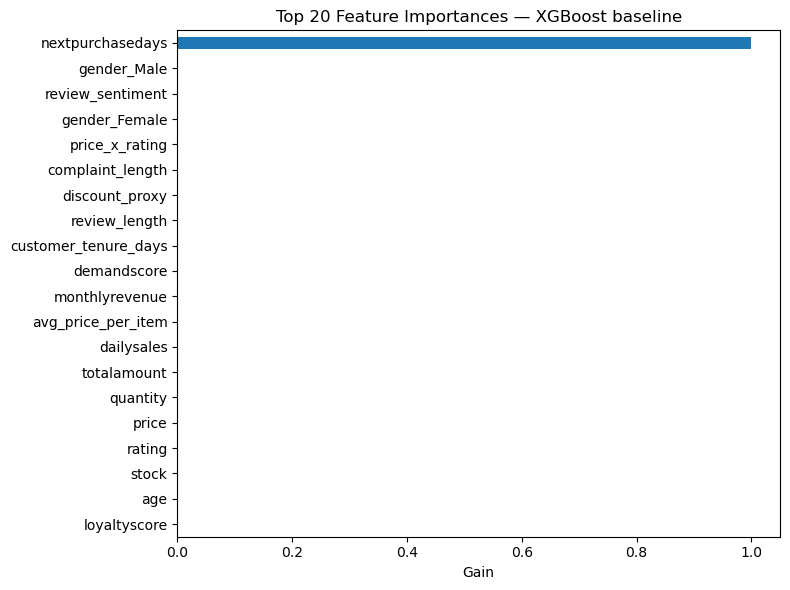

In [36]:
import matplotlib.pyplot as plt

fi = pd.Series(model.feature_importances_, index=X_train_t.columns)
top = fi.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top.sort_values().plot(kind='barh')
plt.title('Top 20 Feature Importances — XGBoost baseline')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

> ✅ **CHECKPOINT** — Expected: **F1 ≈ 0.82**, **ROC-AUC ≈ 0.88**.

---
## 💾 Save Pipeline Artifacts

In [ ]:
import joblib

joblib.dump(preproc, 'k21_preprocessing_pipeline.joblib')
joblib.dump(te,      'k21_target_encoder.joblib')

s3.upload_file('k21_preprocessing_pipeline.joblib', bucket, 'k21-lab/artifacts/preproc.joblib')
s3.upload_file('k21_target_encoder.joblib',         bucket, 'k21-lab/artifacts/target_encoder.joblib')
print('✅ Artifacts saved')

---
## 🧽 Clean-Up

Run this ONCE at the end to avoid charges.

In [ ]:
import boto3

s3_client = boto3.client('s3')
s3_res    = boto3.resource('s3')

# Delete feature group
try:
    from sagemaker.feature_store.feature_group import FeatureGroup
    from sagemaker.session import Session
    fg = FeatureGroup(name='k21-customer-features', sagemaker_session=Session())
    fg.delete()
    print('✅ Deleted feature group: k21-customer-features')
except Exception as e:
    if 'ResourceNotFound' in str(e):
        print('✅ Feature group already deleted')
    else:
        print(f'⚠️  Feature group: {e}')

# Clean up k21-lab/ prefix from default bucket
try:
    default_bucket = Session().default_bucket()
    deleted_count = 0
    for obj in s3_res.Bucket(default_bucket).objects.filter(Prefix='k21-lab/'):
        obj.delete()
        deleted_count += 1
    print(f'✅ Deleted {deleted_count} objects from s3://{default_bucket}/k21-lab/')
except Exception as e:
    print(f'⚠️  {e}')

# Also clean any k21-featureeng-* buckets from older runs
all_buckets = [b['Name'] for b in s3_client.list_buckets()['Buckets']]
old_buckets = [b for b in all_buckets if 'k21-featureeng' in b]
for b in old_buckets:
    try:
        bucket_obj = s3_res.Bucket(b)
        bucket_obj.objects.all().delete()
        bucket_obj.object_versions.all().delete()
        bucket_obj.delete()
        print(f'✅ Deleted old bucket: {b}')
    except Exception as e:
        print(f'⚠️  {b}: {e}')

print('\n🎉 Cleanup complete!')

### 🔴 Final manual step — Stop the JupyterLab space

Python can't stop the JupyterLab space it runs in. Do this in the Studio UI:

1. SageMaker Studio → **JupyterLab**
2. Select your space (e.g., `k21-team`)
3. **Stop space** — and optionally **Delete space**

This is the only step that actually saves money. 🔴


---
## 🎉 Lab Complete

**What you built:**
- ✅ End-to-end feature engineering pipeline on AWS
- ✅ 20+ engineered features
- ✅ Leak-free train/val/test split
- ✅ SageMaker Feature Group (online + offline)
- ✅ Validated baseline with XGBoost

---
*© K21 Academy — [k21academy.com](https://k21academy.com)*
